# Hospital Patient Flow Demand Analysis¶
### First Notebook: Data Preparation and Exploratory Analysis

This notebook focuses on analyzing hospital patient flow to understand operational demand patterns, patient characteristics, and service delivery dynamics.

The objective is to develop a structured analytical foundation for healthcare operations by exploring patient demand, identifying operational bottlenecks, and evaluating key performance indicators related to hospital activity and patient flow.

The analysis uses a real-world hospital operations dataset containing over 9,000 patient encounters recorded between September 2023 and December 2024. The dataset includes patient demographics, arrival timestamps, department referrals, admission decisions, wait times, and satisfaction scores, providing a comprehensive view of hospital activity and operational performance.

This first phase focuses on preparing and structuring the data for exploratory and temporal analysis. Data preparation ensures data quality and consistency, while exploratory analysis examines patient demand patterns, departmental activity, wait times, admission rates, and operational performance.

The overall project explores complementary analytical approaches in healthcare decision support, including time series analysis, mathematical optimization, and multi-criteria decision analysis. Each methodology is developed independently to address different dimensions of healthcare operational planning and decision-making.

The overall goal is to transform operational hospital data into a structured analytical environment capable of supporting evidence-based understanding of demand variability and operational performance.

**Author:** J-F J  
**Date:** July 2026  
**Dataset:** Healthcare Analytics Patient Flow Data (Kaggle)

## 1-Data Loading and Overview

In [1]:
import kagglehub
import pandas as pd

# Download latest version
path = kagglehub.dataset_download("hassanjameelahmed/healthcare-analytics-patient-flow-data")

data_path = "/kaggle/input/datasets/hassanjameelahmed/healthcare-analytics-patient-flow-data/healthcare_analytics_patient_flow_data.csv"

# Clone utility repository
!rm -rf /kaggle/working/jfj-utils
!git clone https://github.com/jfjutras07/jfj-utils.git

# Add to Python path
import sys
sys.path.append("/kaggle/working/jfj-utils")

Cloning into 'jfj-utils'...
remote: Enumerating objects: 3901, done.
remote: Counting objects: 100% (330/330), done.
remote: Compressing objects: 100% (184/184), done.
remote: Total 3901 (delta 272), reused 146 (delta 146), pack-reused 3571 (from 3)
Receiving objects: 100% (3901/3901), 1.30 MiB | 14.26 MiB/s, done.
Resolving deltas: 100% (2565/2565), done.


In [2]:
# Overview
df = pd.read_csv(data_path)
df.head()

,Patient Id,Patient Admission Date,Patient Admission Time,Merged,Patient Gender,Patient Age,Patient Race,Department Referral,Patient Admission Flag,Patient Satisfaction Score,Patient Waittime
0,780-96-6113,9/9/2024,9:25:00 AM,W. Breede,Female,63,African American,NaN,Not Admission,5.0,32
1,714-35-6722,9/9/2024,4:42:00 PM,Y. Baldetti,Male,31,Asian,Orthopedics,Not Admission,NaN,22
2,571-85-3714,9/9/2024,12:14:00 AM,M. Semerad,Male,75,White,General Practice,Not Admission,NaN,16
3,404-43-9499,9/9/2024,8:33:00 PM,K. Blaydes,Male,79,African American,General Practice,Admission,NaN,38
4,552-51-5855,9/9/2024,7:25:00 PM,F. Dickerson,Female,24,African American,NaN,Admission,NaN,36


In [3]:
df.shape

(9216, 11)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9216 entries, 0 to 9215
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Patient Id                  9216 non-null   object 
 1   Patient Admission Date      9216 non-null   object 
 2   Patient Admission Time      9216 non-null   object 
 3   Merged                      9216 non-null   object 
 4   Patient Gender              9216 non-null   object 
 5   Patient Age                 9216 non-null   int64  
 6   Patient Race                9216 non-null   object 
 7   Department Referral         3816 non-null   object 
 8   Patient Admission Flag      9216 non-null   object 
 9   Patient Satisfaction Score  2517 non-null   float64
 10  Patient Waittime            9216 non-null   int64  
dtypes: float64(1), int64(2), object(8)
memory usage: 792.1+ KB


The dataset contains 9,216 patient encounters described by 11 variables capturing patient demographics, arrival information, clinical workflow, and operational performance. Each observation represents a single hospital visit and provides a realistic foundation for exploratory analysis and temporal demand analysis.

### Column Description

| Column                         | Description                                                                             |
| ------------------------------ | --------------------------------------------------------------------------------------- |
| **Patient Id**                 | Unique anonymized identifier for each patient encounter.                                |
| **Patient Admission Date**     | Date when the patient arrived at the hospital.                                          |
| **Patient Admission Time**     | Time of patient arrival.                                                                |
| **Merged**                     | Text field identified in the original Kaggle dataset as a corrupted name column with no analytical value that will be removed during data preparation.                 |
| **Patient Gender**             | Patient's gender.                                                                       |
| **Patient Age**                | Patient's age in years.                                                                 |
| **Patient Race**               | Patient's self-reported race or ethnicity.                                              |
| **Department Referral**        | Hospital department to which the patient was referred, if applicable.                   |
| **Patient Admission Flag**     | Indicates whether the patient was admitted or not (target variable for classification). |
| **Patient Satisfaction Score** | Patient satisfaction rating on a scale from 0 to 10.                                    |
| **Patient Waittime**           | Patient waiting time before receiving care, measured in minutes.                        |


## 2-Data Quality Assessment

In [5]:
from eda.describe_structure import describe_structure
describe_structure(df)


=== Numeric Columns ===

                             count       mean        std   min   25%   50%  \
Patient Age                 9216.0  39.855143  22.755125   1.0  20.0  39.0   
Patient Satisfaction Score  2517.0   4.992054   3.138043   0.0   2.0   5.0   
Patient Waittime            9216.0  35.259874  14.735323  10.0  23.0  35.0   

                             75%   max  
Patient Age                 60.0  79.0  
Patient Satisfaction Score   8.0  10.0  
Patient Waittime            48.0  60.0  

=== Boolean Columns ===

Empty DataFrame
Columns: []
Index: []

=== Categorical Columns ===

                        unique_values     most_frequent  \
Patient Gender                    3.0              Male   
Patient Race                      7.0             White   
Department Referral               7.0  General Practice   
Patient Admission Flag            2.0         Admission   

                                                        all_unique_values  \
Patient Gender                

The dataset is generally complete, with most variables containing no missing values. Two exceptions require attention: Department Referral has 58.6% missing values, likely because many patients did not require referral to a specialized department, while Patient Satisfaction Score has 72.7% missing values, suggesting that satisfaction surveys were completed for only a subset of patients. Additionally, the Merged column appears to be an unrelated text field and will be evaluated for removal during data cleaning.

## 3-Data Preparation for Exploratory Analysis

Before conducting the exploratory data analysis, the date and time variables will be converted to appropriate datetime formats to facilitate temporal analyses. This transformation changes only the data type and preserves the original information without modifying the underlying data.

In [6]:
from eda.date_formats import detect_date_patterns, date_quality

# Detect date string patterns before conversion
date_columns = ["Patient Admission Date", "Patient Admission Time"]

date_patterns = detect_date_patterns(df, date_columns)

for col, patterns in date_patterns.items():
    print(f"\n{col}")
    for pattern in sorted(patterns):
        print(f" - {pattern}")


Patient Admission Date
 - d/d/dddd
 - d/dd/dddd
 - dd/d/dddd
 - dd/dd/dddd

Patient Admission Time
 - d:dd:dd aa
 - dd:dd:dd aa


In [7]:
date_quality = date_quality(
    df,
    ["Patient Admission Date"]
)

date_quality

{'Patient Admission Date': {'total_values': 9216,
  'day_first_dates': 5603,
  'month_first_dates': 0,
  'ambiguous_dates': 3613,
  'invalid_dates': 0,
  'mixed_format_detected': False,
  'missing_values': np.int64(0),
  'missing_percentage': np.float64(0.0)}}

Since date formats are often inconsistent in operational datasets, the original date strings were examined before conversion. The results provide sufficient evidence that the dataset follows a day-first (DD/MM/YYYY) format, supporting a reliable datetime conversion.

In [8]:
# Data type conversion

# Remove irrelevant column
df = df.drop(columns="Merged")

# ID
df["Patient Id"] = df["Patient Id"].astype("string")

# Date
df["Patient Admission Date"] = pd.to_datetime(
    df["Patient Admission Date"],
    dayfirst=True,
    errors="coerce"
)

# Time (stored as datetime for easier manipulation)
df["Patient Admission Time"] = pd.to_datetime(
    df["Patient Admission Time"],
    format="%I:%M:%S %p",
    errors="coerce"
)

# Categorical variables
categorical_cols = [
    "Patient Gender",
    "Patient Race",
    "Department Referral",
    "Patient Admission Flag"
]

df[categorical_cols] = df[categorical_cols].astype("category")

# Numeric variables
numeric_cols = [
    "Patient Age",
    "Patient Satisfaction Score",
    "Patient Waittime"
]

df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors="coerce")

In [9]:
describe_structure(
    df,
    id_cols="Patient Id",
    date_cols=["Patient Admission Date", "Patient Admission Time"]
)


=== Numeric Columns ===

                             count       mean        std   min   25%   50%  \
Patient Age                 9216.0  39.855143  22.755125   1.0  20.0  39.0   
Patient Satisfaction Score  2517.0   4.992054   3.138043   0.0   2.0   5.0   
Patient Waittime            9216.0  35.259874  14.735323  10.0  23.0  35.0   

                             75%   max  
Patient Age                 60.0  79.0  
Patient Satisfaction Score   8.0  10.0  
Patient Waittime            48.0  60.0  

=== Boolean Columns ===

Empty DataFrame
Columns: []
Index: []

=== Categorical Columns ===

                        unique_values     most_frequent  \
Patient Gender                    3.0              Male   
Patient Race                      7.0             White   
Department Referral               7.0  General Practice   
Patient Admission Flag            2.0         Admission   

                                                        all_unique_values  \
Patient Gender                

## 4-EDA

The exploratory data analysis is organized progressively, moving from individual variable exploration to multivariate and temporal analyses. This structure provides a comprehensive understanding of patient flow patterns, operational variability, and key factors influencing hospital activity.

| Phase                     | Objective                                                                         | Main Analyses                                                                                                                     |
| ------------------------- | --------------------------------------------------------------------------------- | --------------------------------------------------------------------------------------------------------------------------------- |
| **Univariate Analysis**   | Understand the distribution and quality of individual variables.                  | Numerical distributions, categorical frequencies, missing values, outlier detection.                                              |
| **Bivariate Analysis**    | Explore relationships between pairs of variables relevant to hospital operations. | Wait time vs. admission, department vs. admission, satisfaction vs. wait time, age vs. admission, correlation analysis.           |
| **Multivariate Analysis** | Identify interactions among multiple variables affecting patient flow.            | Cross-tabulations, grouped summaries, correlation matrix, operational comparisons across departments and patient characteristics. |
| **Temporal Analysis**     | Examine demand patterns and operational dynamics over time.                       | Patient arrivals by hour, day, week, and month; weekday patterns; temporal evolution of wait times and admissions.                |


### Univariate Analysis

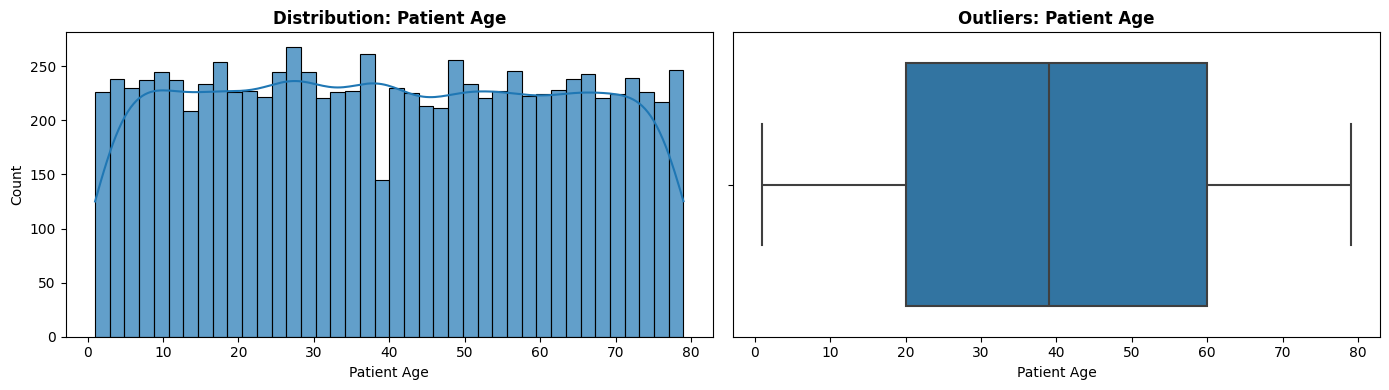

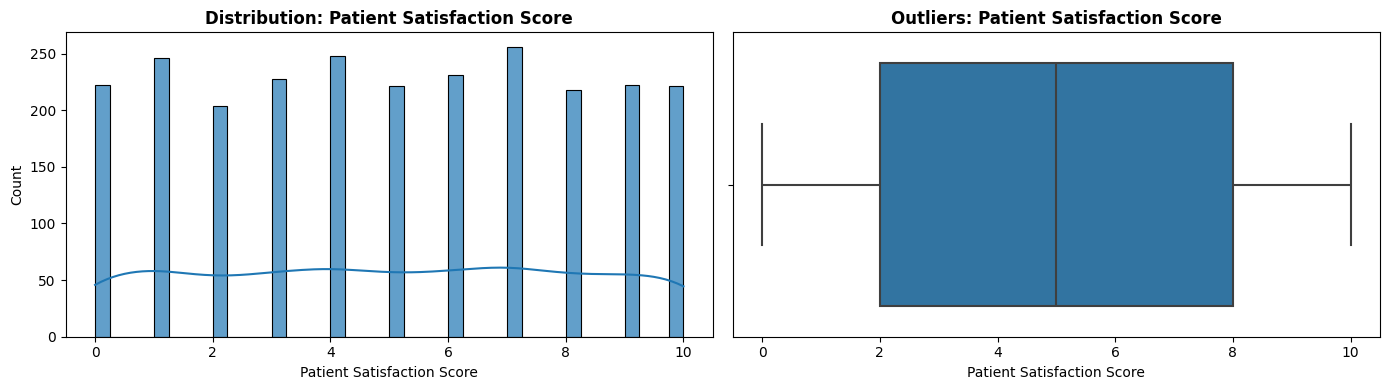

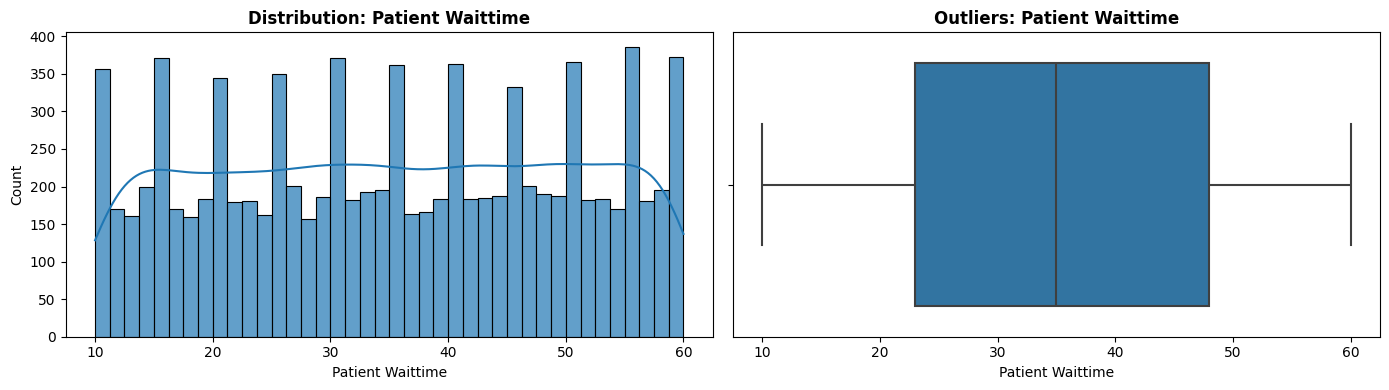

In [10]:
from visualization.explore_continuous import plot_numeric_distribution
plot_numeric_distribution(df, numeric_cols)

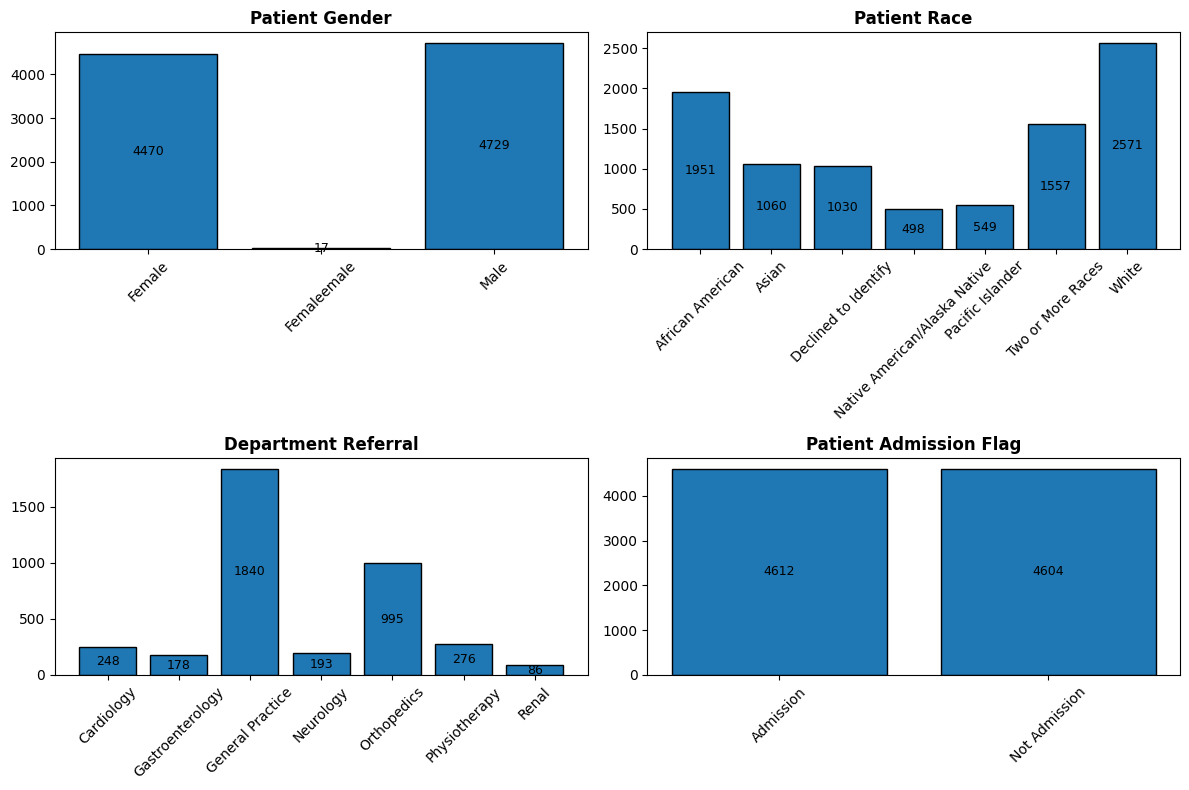

In [11]:
from visualization.explore_discrete import plot_discrete_distribution_grid
plot_discrete_distribution_grid(df, categorical_cols)

Patient age and wait time exhibit nearly symmetric distributions, with mean and median values that are almost identical and no evidence of substantial skewness. Satisfaction scores are also approximately symmetric but contain 72.7% missing values, indicating that subsequent analyses involving this variable should be interpreted with caution.

The sample is well balanced by gender and admission status, while patient race is reasonably distributed across several categories. Department referrals are dominated by missing values (58.6%), with General Practice and Orthopedics representing the most frequent referral destinations among recorded cases.

### Bivariate Analysis

In [12]:
from visualization.explore_continuous import plot_box_grid, plot_scatter_grid, plot_correlation_heatmap
from visualization.explore_discrete_multivariate import plot_discrete_bivariate_grid

**Patient Waittime by Admission Status**

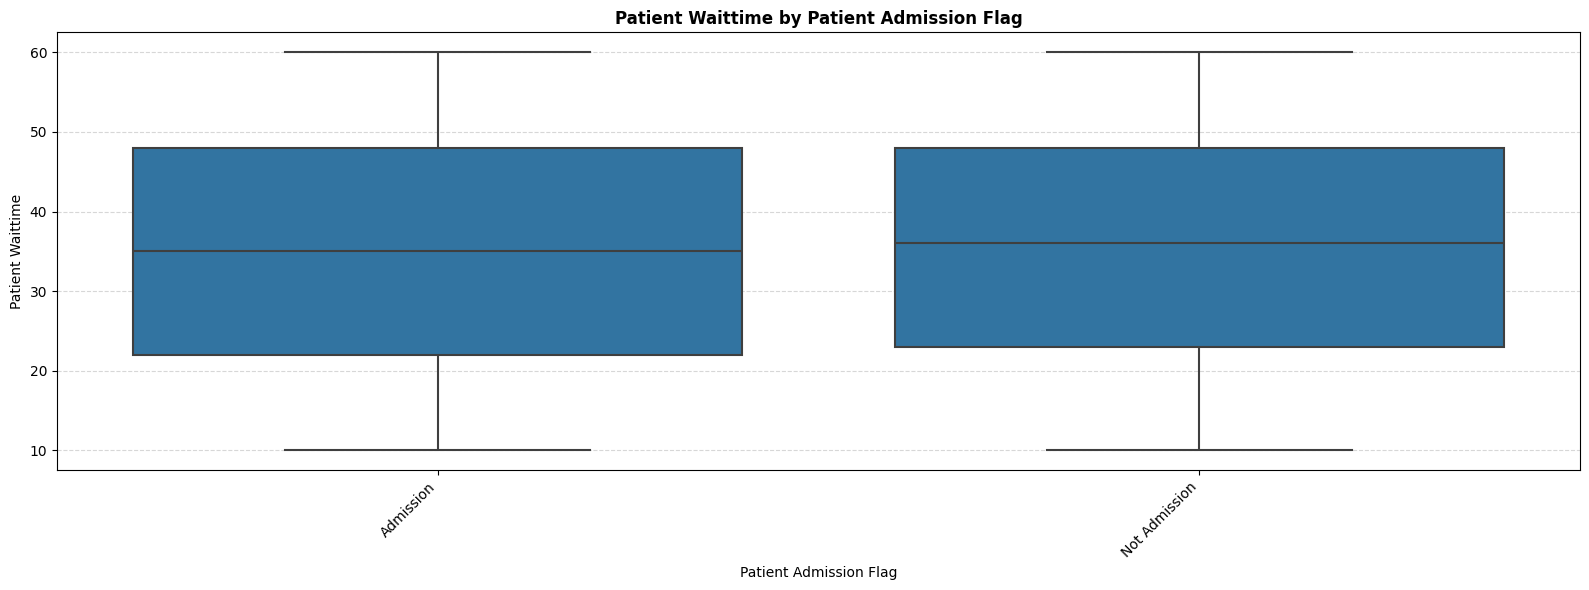

In [13]:
plot_box_grid(
    df,
    value_cols="Patient Waittime",
    group_col="Patient Admission Flag"
)

**Patient Watitime by Department Referral**

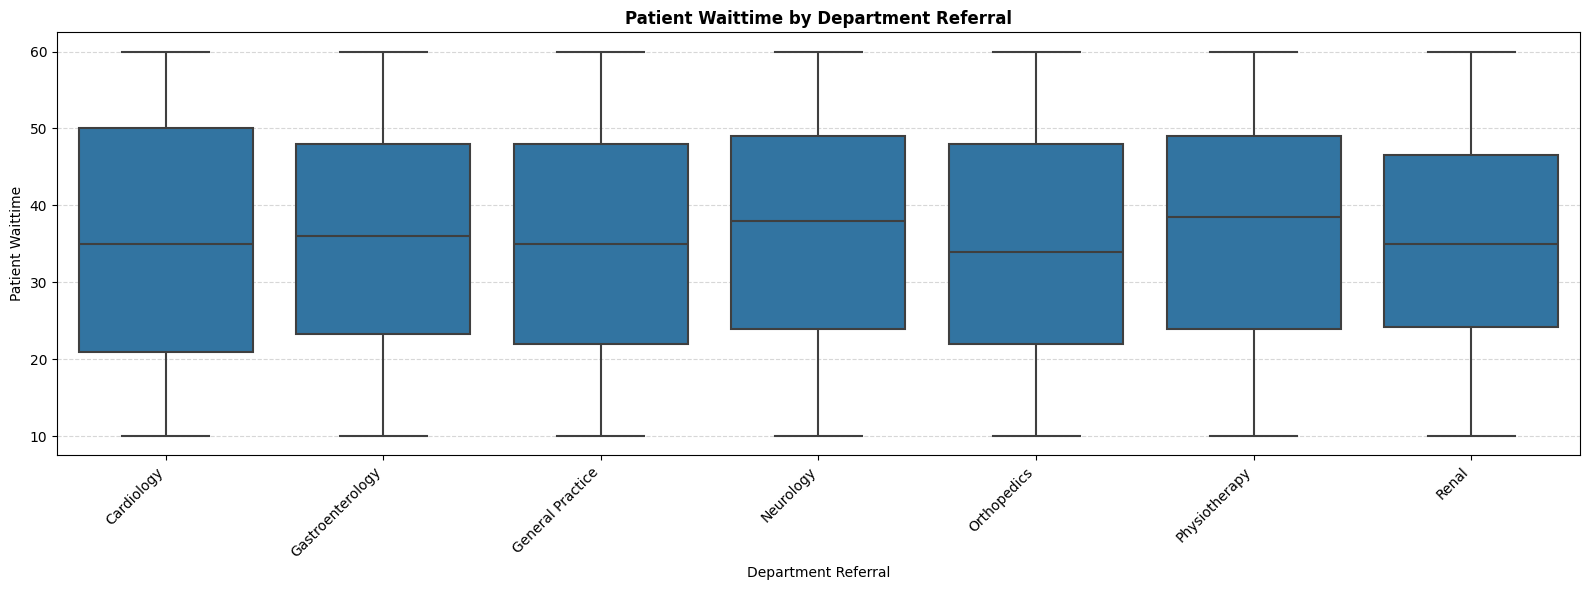

In [14]:
plot_box_grid(
    df,
    value_cols="Patient Waittime",
    group_col="Department Referral"
)

**Patient Age by Patient Admission Flag**

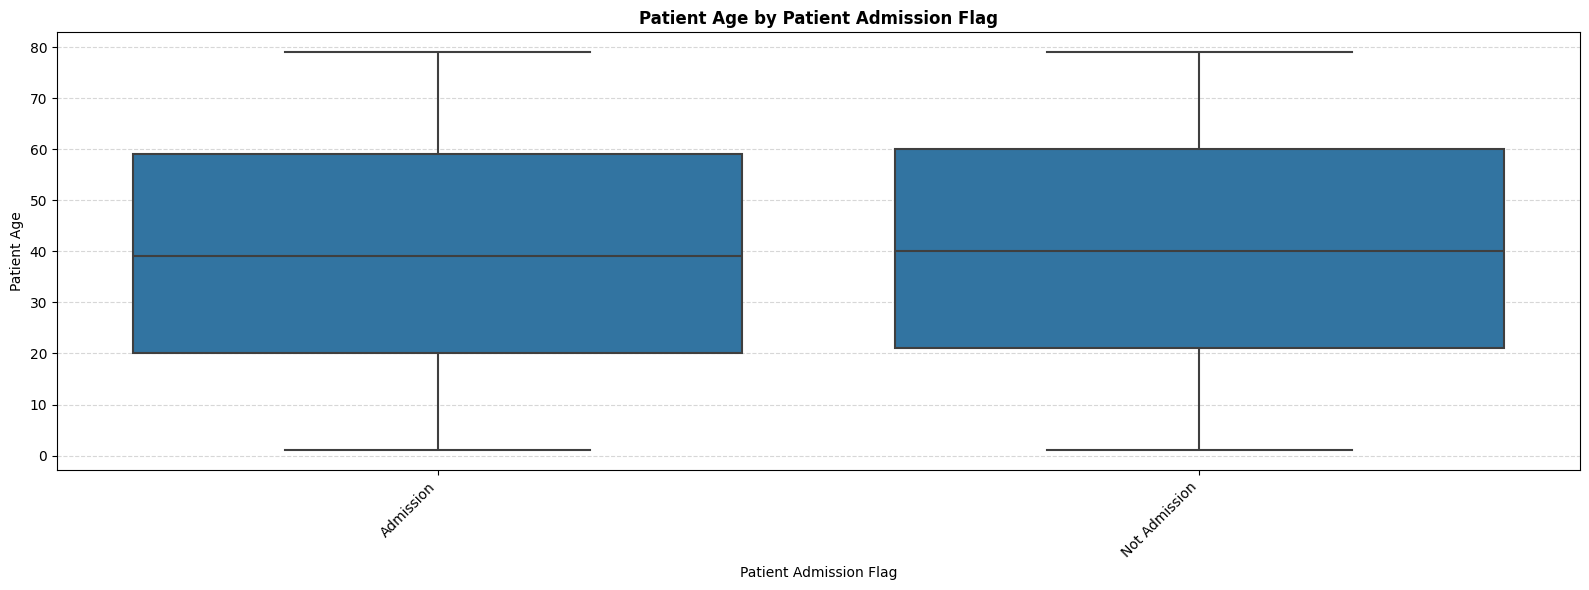

In [15]:
plot_box_grid(
    df,
    value_cols="Patient Age",
    group_col="Patient Admission Flag"
)

**Patient Satisfaction Score vs Patient Waittime**

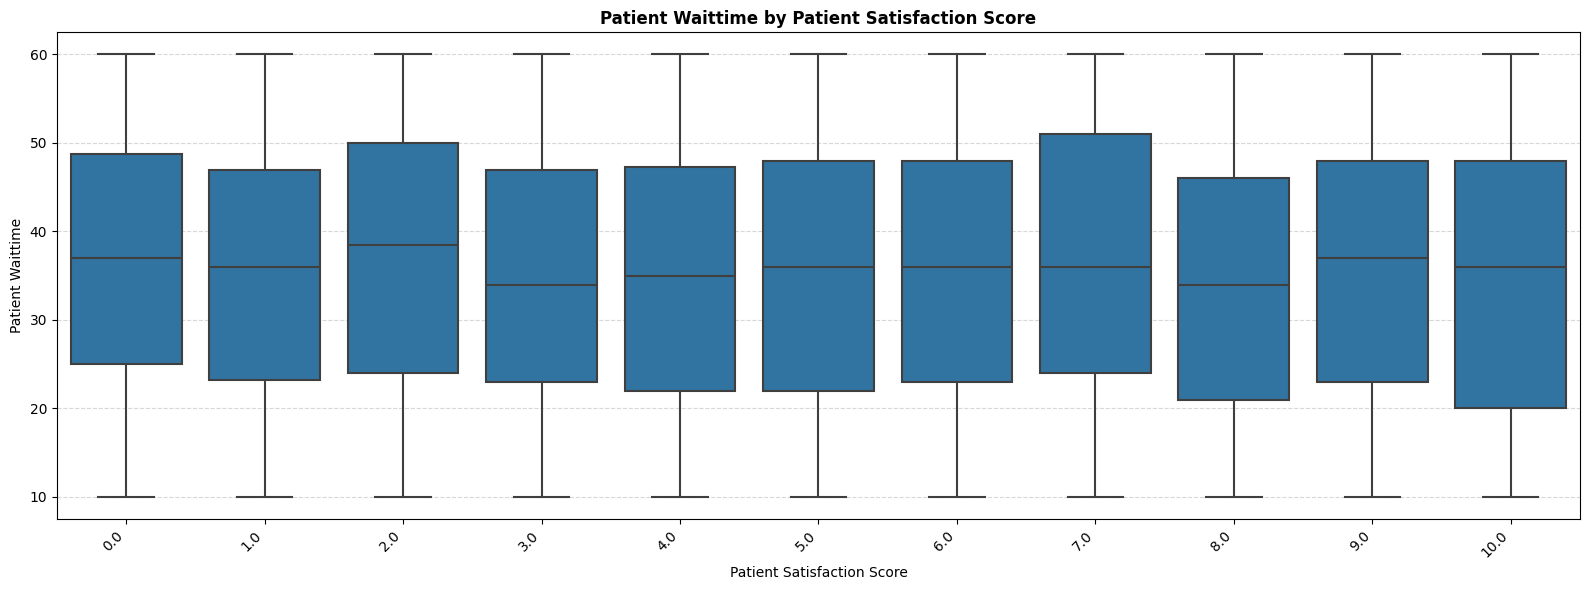

In [16]:
# Remove missing satisfaction scores before analyzing the relationship
# between patient wait time and satisfaction score

df_satisfaction = df.dropna(
    subset=["Patient Satisfaction Score"]
)

plot_box_grid(
    df_satisfaction,
    value_cols="Patient Waittime",
    group_col="Patient Satisfaction Score"
)

**Department Referral by Patient Admission Flag**

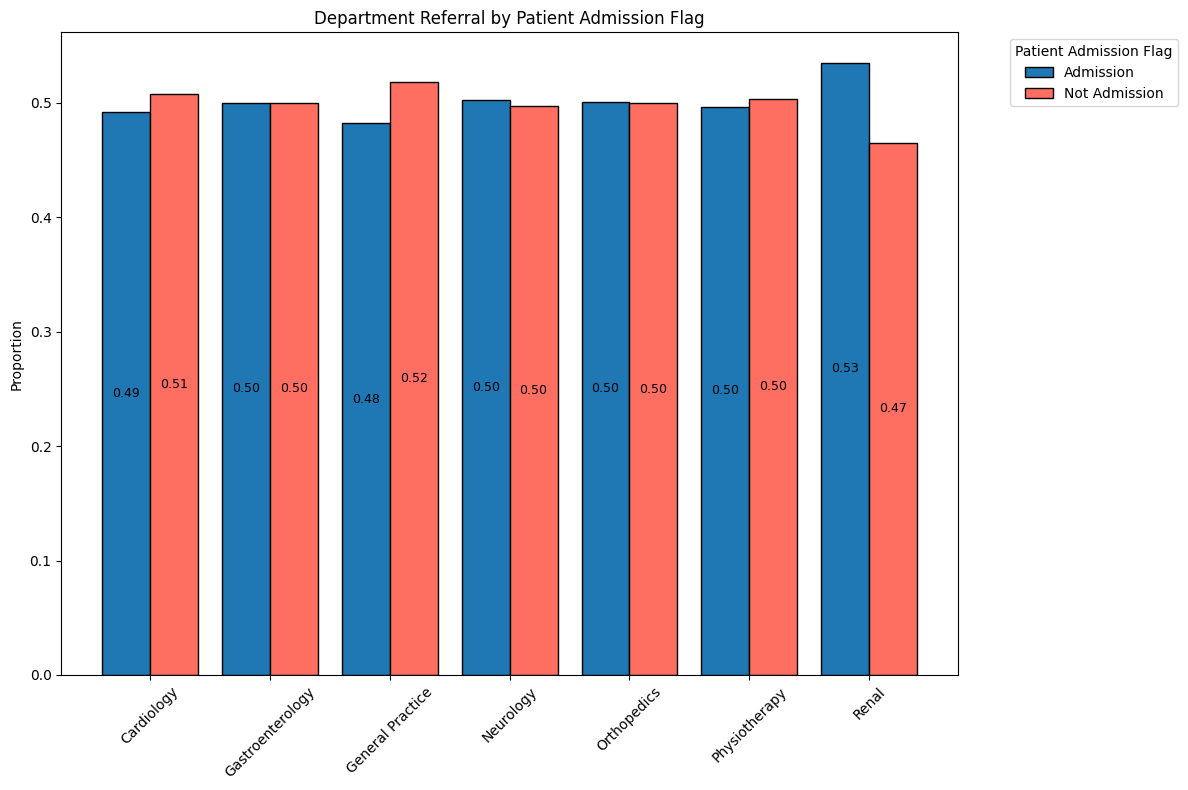

In [17]:
plot_discrete_bivariate_grid(
    df,
    discrete_cols="Department Referral",
    hue_col="Patient Admission Flag",
    show_proportion=True
)

**Correlation Analysis of Numerical Variables**

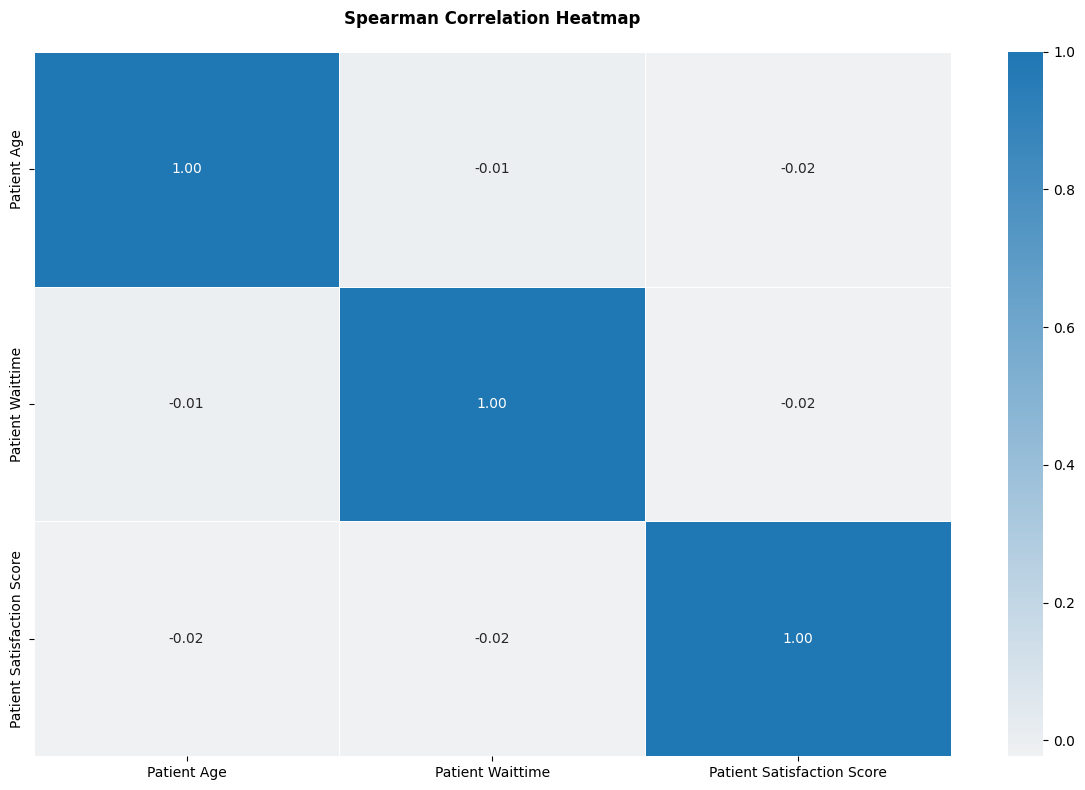

In [18]:
plot_correlation_heatmap(
    df,
    numeric_cols=[
        "Patient Age",
        "Patient Waittime",
        "Patient Satisfaction Score"
    ]
)

Bivariate analysis shows that patient wait time is relatively consistent across admission status, departments, and satisfaction levels, with average values remaining close to 35 minutes. No meaningful relationship is observed between waiting time and admission outcome, suggesting other factors influence admission decisions. Department-level differences are limited, although Neurology and Physiotherapy show slightly higher average waiting times. Age distributions are nearly identical between admitted and non-admitted patients. Finally, the weak correlations indicate limited linear relationships among age, wait time, and satisfaction, supporting the need for more advanced temporal and operational analyses.

### Multivariate Analysis

In [19]:
from visualization.explore_continuous import plot_heatmap_grid, plot_pairplot
from visualization.explore_discrete_multivariate import plot_stacked_grid

**Patient Waittime by Department Referral and Patient Admission Flag**

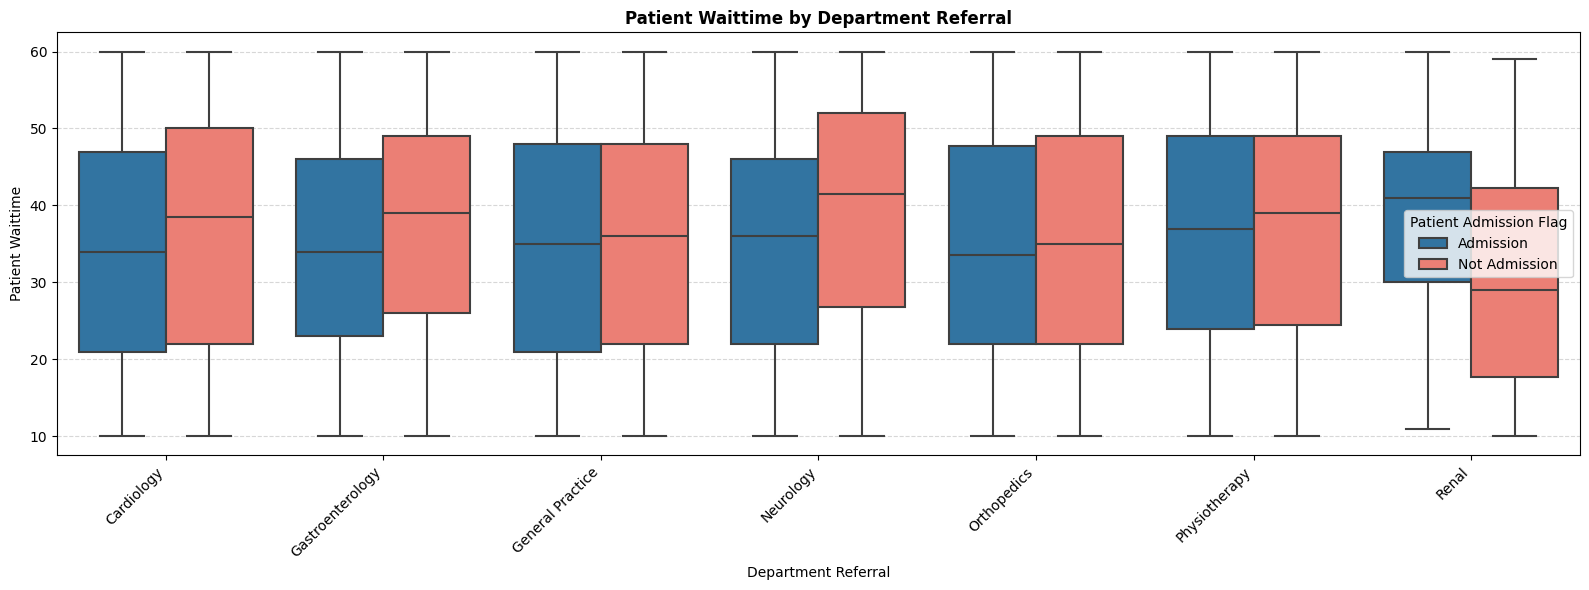

In [20]:
plot_box_grid(
    df,
    value_cols="Patient Waittime",
    group_col="Department Referral",
    hue_col="Patient Admission Flag"
)

**Patient Satisfaction Score by Patient Waittime and Patient Admission Flag**

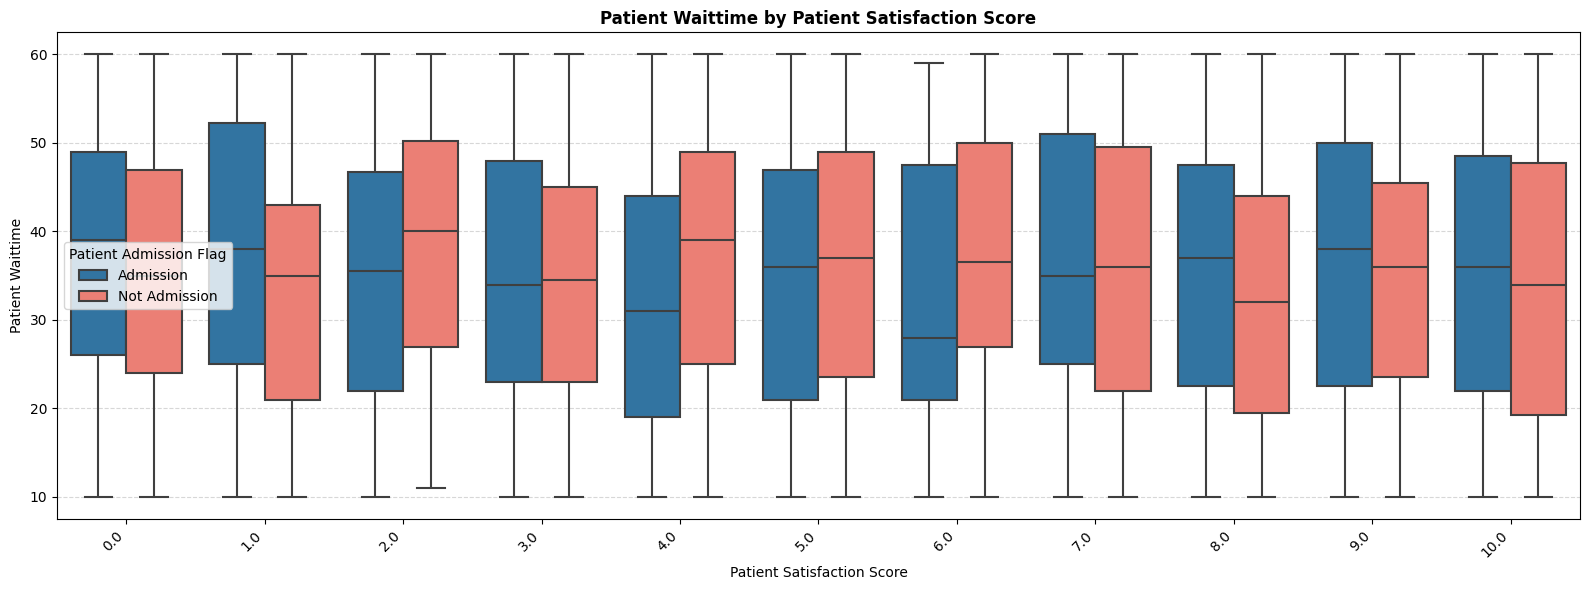

In [21]:
plot_box_grid(
    df_satisfaction,
    value_cols="Patient Waittime",
    group_col="Patient Satisfaction Score",
    hue_col="Patient Admission Flag"
)

**Patient Waittime by Admission Day and Admission Hour**

In [22]:
# Create temporal features for multivariate analysis
# Time-only variables are stored as datetime objects by pandas, which adds
# a default reference date (1900-01-01). Only the extracted time components
# are used for temporal analysis.

df["Admission Hour"] = df["Patient Admission Time"].dt.hour

df["Admission Day"] = df["Patient Admission Date"].dt.day_name()

# Quick check
df[["Patient Admission Date", "Patient Admission Time", "Admission Day", "Admission Hour"]].head()

,Patient Admission Date,Patient Admission Time,Admission Day,Admission Hour
0,2024-09-09,1900-01-01 09:25:00,Monday,9
1,2024-09-09,1900-01-01 16:42:00,Monday,16
2,2024-09-09,1900-01-01 00:14:00,Monday,0
3,2024-09-09,1900-01-01 20:33:00,Monday,20
4,2024-09-09,1900-01-01 19:25:00,Monday,19


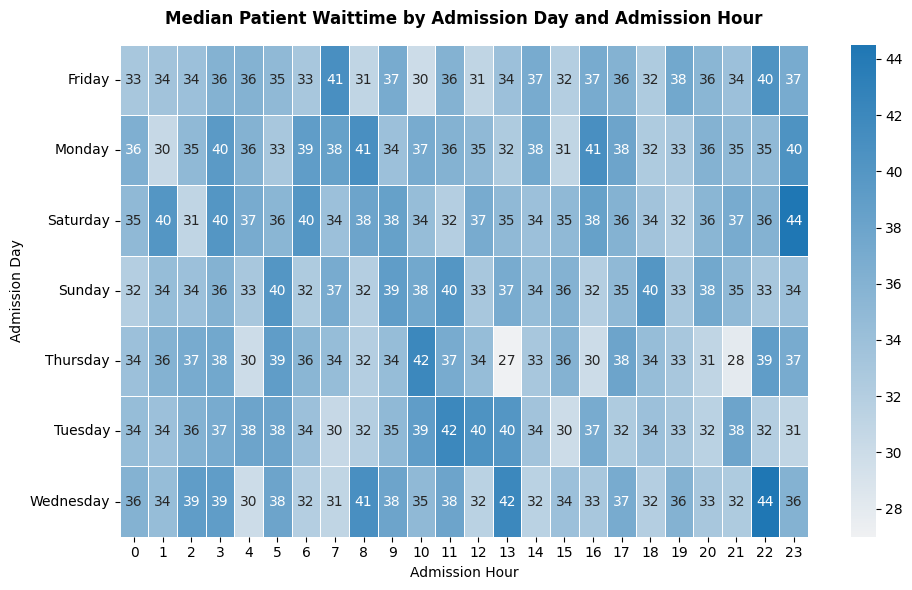

In [23]:
plot_heatmap_grid(
    df,
    value_col="Patient Waittime",
    index_col="Admission Day",
    columns_col="Admission Hour",
    aggfunc="median"
)

**Patient Admission Flag by Department Referral and Age Group**

In [24]:
# Create age groups for multivariate admission analysis
df["Age Group"] = pd.cut(
    df["Patient Age"],
    bins=[0, 18, 35, 50, 65, 80],
    labels=[
        "0-18",
        "19-35",
        "36-50",
        "51-65",
        "66+"
    ]
)

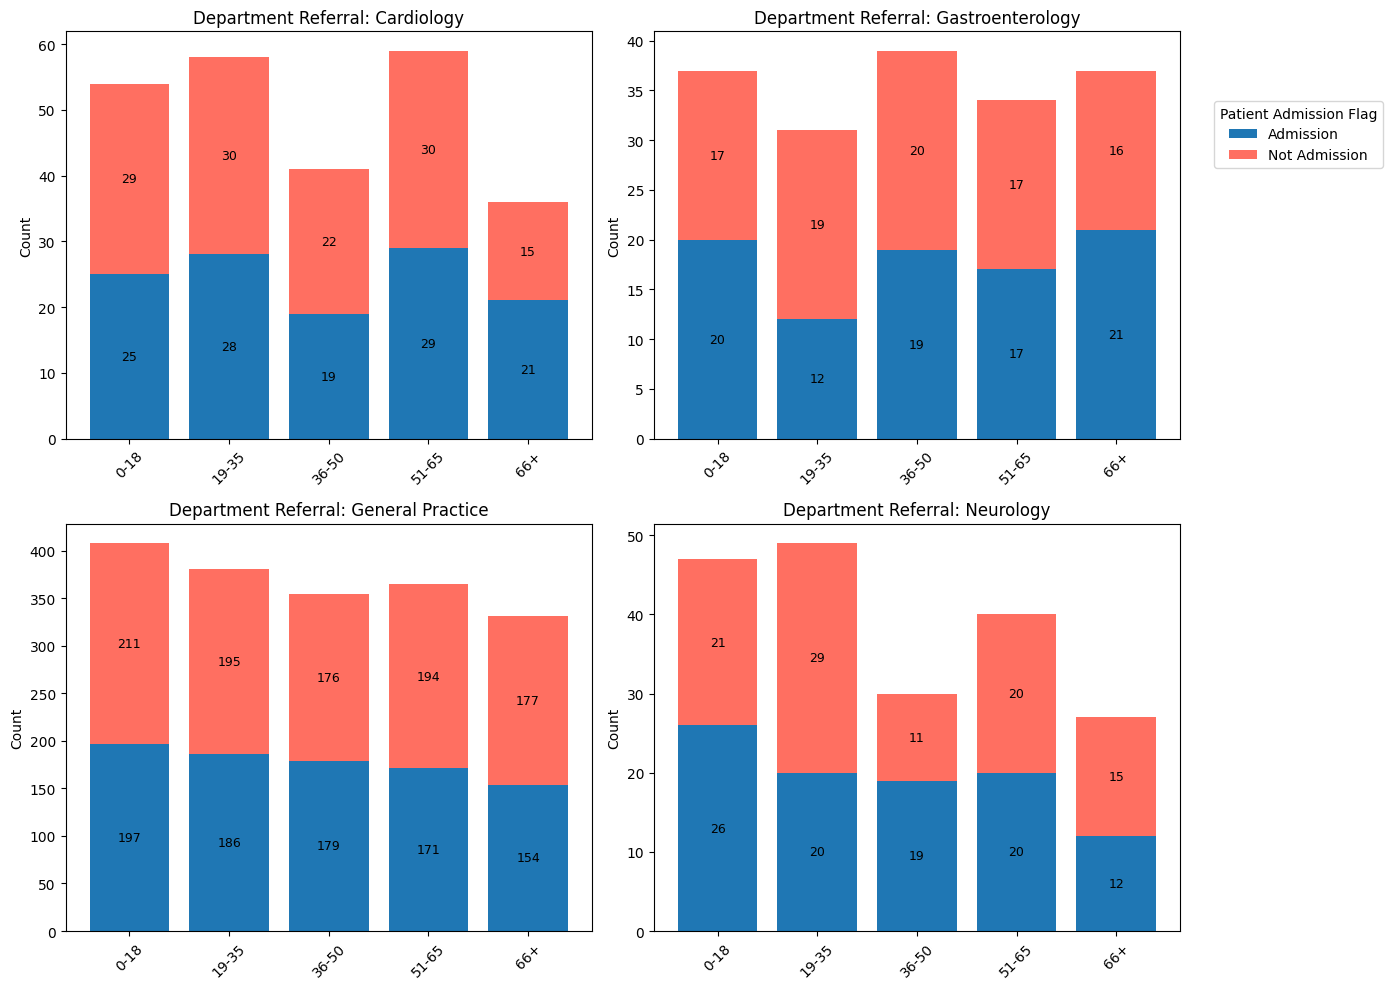

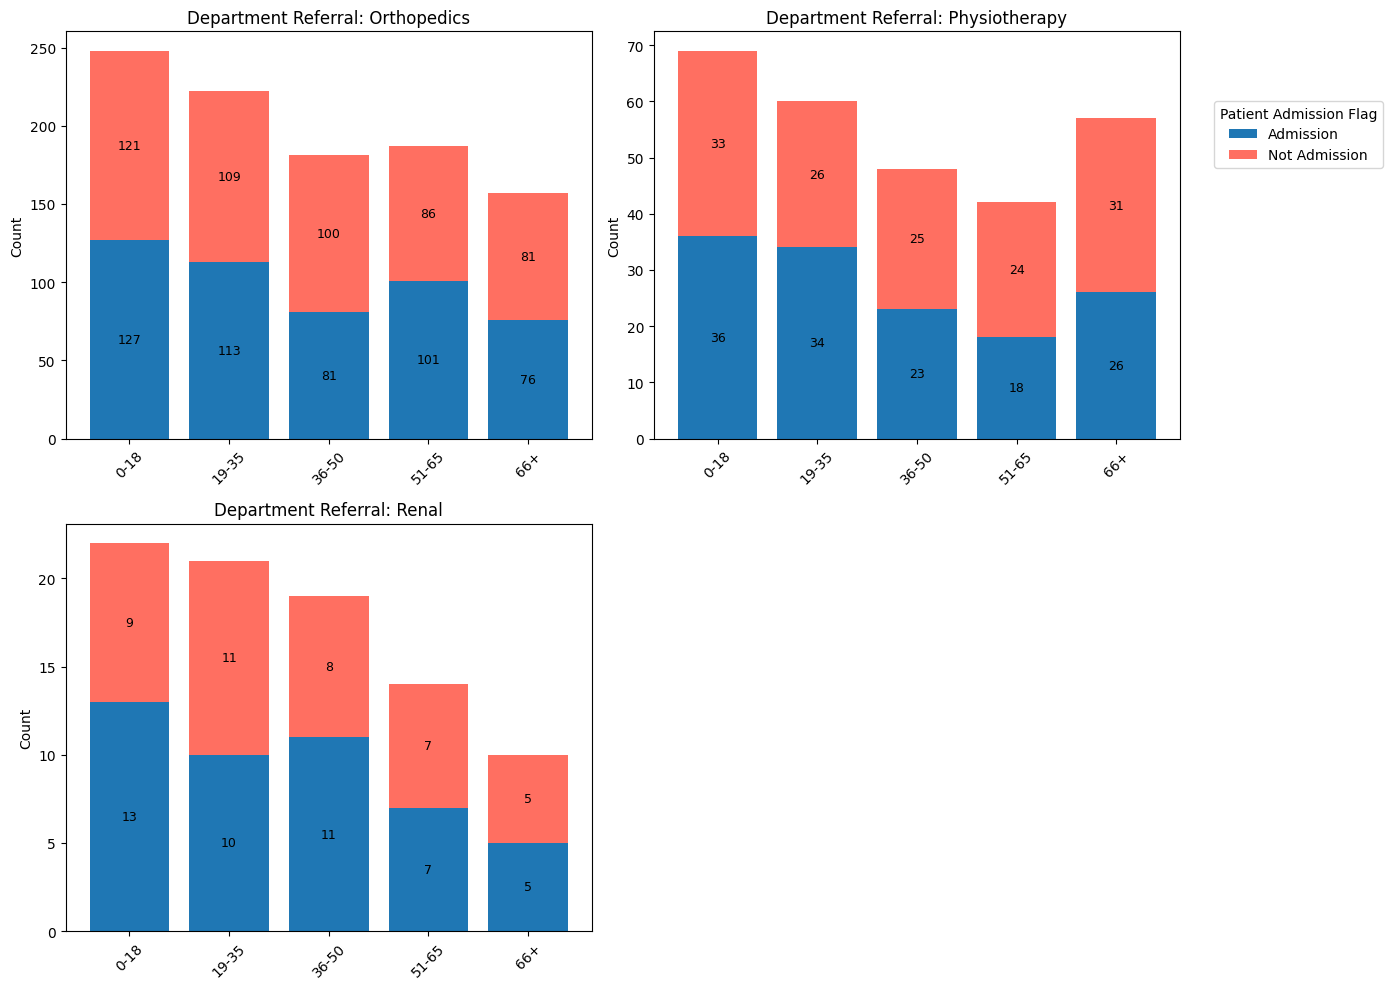

In [25]:
plot_stacked_grid(
    df,
    dependent_var="Patient Admission Flag",
    group_vars=[
        "Department Referral",
        "Age Group"
    ]
)

The multivariate analysis shows that waiting times remain relatively stable across departments and admission status, with only moderate differences observed in specific departments (e.g., Neurology and Gastroenterology). Patient satisfaction and waiting times do not show meaningful differences between admitted and non-admitted patients. Temporal patterns by day and hour reveal some fluctuations, but no strong congestion pattern is identified. Finally, admission rates vary mainly across department and age group combinations, suggesting slightly different patient profiles across clinical pathways.

### Temporal Analysis

In [26]:
from visualization.explore_time import plot_line_grid_over_time, plot_temporal_data

#Create temporal variables
df["Admission Hour"] = df["Patient Admission Time"].dt.hour
df["Admission Day"] = df["Patient Admission Date"].dt.day_name()
df["Admission Date"] = df["Patient Admission Date"].dt.date
df["Admission Month"] = df["Patient Admission Date"].dt.to_period("M").astype(str)

**Patient arrivals over time**

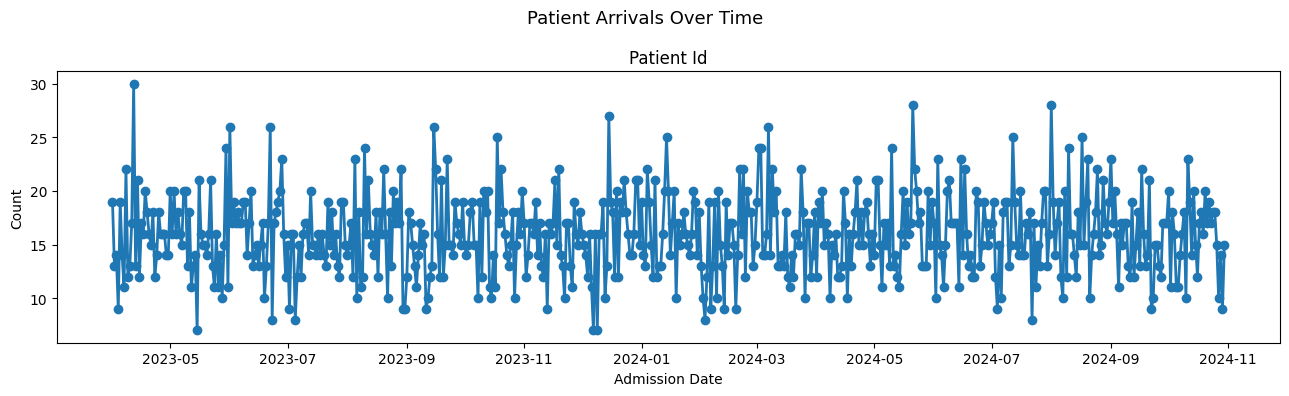

In [27]:
plot_line_grid_over_time(
    df,
    value_cols="Patient Id",
    time_col="Admission Date",
    agg_func="count",
    title="Patient Arrivals Over Time"
)

**Patient Waittime Evolution Over Time**

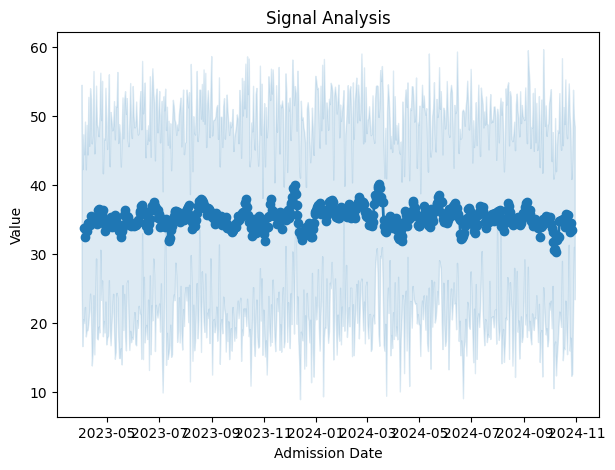

In [28]:
plot_temporal_data(
    df,
    value_cols="Patient Waittime",
    time_col="Admission Date",
    agg_func="mean",
    rolling_window=7,
    show_std=True,
    title="Patient Waittime Evolution Over Time"
)

**Patient arrivals by hour of day**

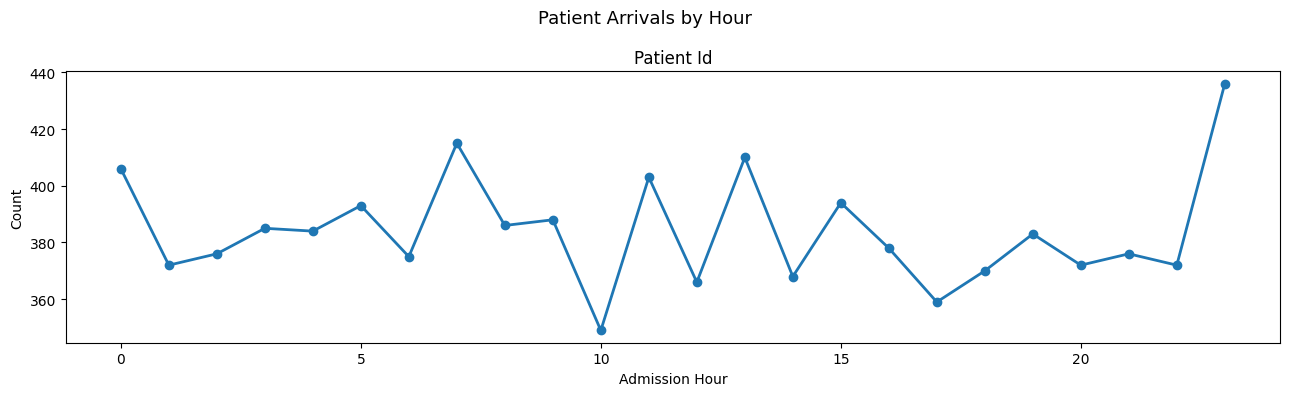

In [29]:
plot_line_grid_over_time(
    df,
    value_cols="Patient Id",
    time_col="Admission Hour",
    agg_func="count",
    title="Patient Arrivals by Hour"
)

**Patient arrivals by day of week**

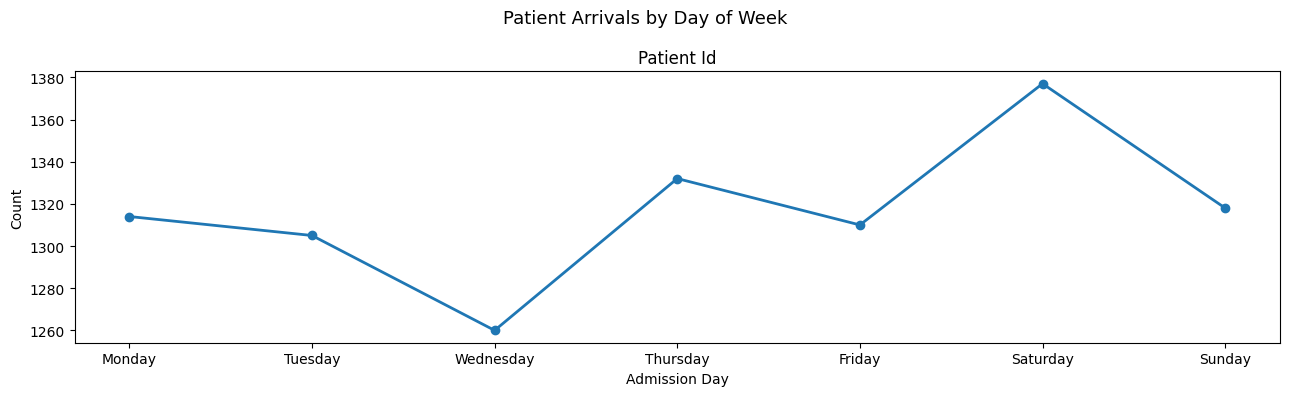

In [30]:
# Create ordered weekday variable for temporal analysis
weekday_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

df["Admission Day"] = pd.Categorical(
    df["Admission Day"],
    categories=weekday_order,
    ordered=True
)

# Call function
plot_line_grid_over_time(
    df,
    value_cols="Patient Id",
    time_col="Admission Day",
    agg_func="count",
    title="Patient Arrivals by Day of Week"
)

Temporal analysis indicates a relatively stable patient demand pattern, with an average of 15.9 arrivals per day and limited variation across the 579-day observation period. Waiting times remained consistent over time, with a daily average around 35 minutes and no evidence of persistent temporal congestion. Arrival volumes were evenly distributed across hours and weekdays, with only minor peaks observed (e.g., Saturday and late evening arrivals).

## 5-Statistical Validation of Operational Patterns

Exploratory data analysis provides an initial understanding of patient flow patterns; however, visual observations alone may not be sufficient to determine whether observed differences represent meaningful operational variations. Therefore, selected statistical tests are applied to validate key relationships identified during the exploratory phase.

Rather than performing an exhaustive set of statistical tests across all available variables, the analyses focus on relationships with direct operational relevance for hospital management and performance evaluation. This targeted approach avoids unnecessary hypothesis testing, reduces the risk of identifying statistically significant but operationally irrelevant patterns, and prioritizes insights that improve the understanding of hospital activity and patient flow dynamics.

The selected methods are adapted to the structure and distributional properties of the data:

- non-parametric tests are used for continuous operational variables that did not satisfy normality assumptions;
- chi-square tests are used to evaluate associations between categorical operational factors;
- effect size measures are considered alongside statistical significance to assess practical relevance.

**Waiting Time Differences Across Departments**

In [31]:
import sys
!{sys.executable} -m pip install pingouin scikit-posthocs scikit-bio statsmodels -q
from eda.stats_non_param import kruskal_wallis_test

kw_department = kruskal_wallis_test(
    df,
    column="Patient Waittime",
    group="Department Referral"
)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.0/204.0 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 50.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.1/79.1 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 50.1 MB/s eta 0:00:00
Kruskal-Wallis test for Patient Waittime by Department Referral
H-statistic = 5.9241, p-value = 0.4317
Epsilon squared = -0.0000


The Kruskal-Wallis test was applied to evaluate whether patient waiting times differed across referral departments. The results indicate no statistically significant differences between departments (H = 5.92, p = 0.432). 

Furthermore, the epsilon squared effect size was approximately zero, suggesting that department referral explains a negligible proportion of waiting time variability. These results indicate that department-specific differences alone are unlikely to represent a major driver of patient waiting times in this dataset.

**Waiting Time Diffrences Across Admission Status**

In [32]:
from eda.stats_non_param import mann_whitney_cliff

mw_waittime = mann_whitney_cliff(
    df,
    value_col="Patient Waittime",
    group_col="Patient Admission Flag",
    group1="Admission",
    group2="Not Admission"
)

mw_waittime

Group 1             Admission
Group 2         Not Admission
n_group1                 4612
n_group2                 4604
U_statistic        10374560.5
p_value              0.057777
Cliffs_delta        -0.022819
dtype: object

The Mann-Whitney U test was used to compare patient waiting times between admitted and non-admitted patients. Results indicate no statistically significant difference between the two groups (U = 10,374,560.5, p = 0.058). Furthermore, Cliff's delta showed a negligible effect size (δ = -0.023), indicating that admission status does not meaningfully influence patient waiting time in this dataset. These findings suggest that waiting time alone is unlikely to be a primary determinant of admission decisions.

**Association Between Operational Factors and Admission Decisions**

In [33]:
from eda.chi_square_test import chi_square_test

# Department Referral vs Admission Flag
chi_department = chi_square_test(
    df,
    col1="Department Referral",
    col2="Patient Admission Flag"
)


Chi-square test for Department Referral vs Patient Admission Flag:
Chi2 = 1.80, p-value = 0.9373, dof = 6
Cramér's V = 0.022


In [34]:
# Age Group and Admission Flag
chi_age = chi_square_test(
    df,
    col1="Age Group",
    col2="Patient Admission Flag"
)


Chi-square test for Age Group vs Patient Admission Flag:
Chi2 = 1.73, p-value = 0.7849, dof = 4
Cramér's V = 0.014


In [35]:
# Gender and Admission Flag
chi_gender = chi_square_test(
    df,
    col1="Patient Gender",
    col2="Patient Admission Flag"
)


Chi-square test for Patient Gender vs Patient Admission Flag:
Chi2 = 1.48, p-value = 0.4763, dof = 2
Cramér's V = 0.013


The chi-square analyses showed no significant associations between operational or demographic factors and patient admission status. Department referral, age group, and gender all presented negligible effect sizes, indicating that these variables alone provide limited explanatory power for admission decisions in this dataset.

## 6-Summary - Notebook 1

| Element | Objective | Methods / Tools | Key Findings | Decision Support Implications |
|---|---|---|---|---|
| Data Loading and Overview | Understand dataset structure | Dataset inspection and descriptive overview | 9,216 patient encounters with operational, demographic, and outcome variables | Dataset suitable for patient flow analysis |
| Data Quality Assessment | Evaluate data reliability | Missing values, data types, consistency checks | Missing values identified mainly for referrals and satisfaction scores; irrelevant fields removed | Data limitations documented before analysis |
| Data Preparation | Structure data for analysis | Date/time conversion, variable transformation, feature creation | Dataset successfully standardized and prepared for analytical workflows | Ready for exploratory and temporal analysis |
| Exploratory Data Analysis | Identify patient flow patterns | Univariate, bivariate, multivariate, and temporal analysis | Stable waiting times, balanced demand, limited differences across groups | Provides insights into operational variability and patient flow dynamics |
| Statistical Validation | Confirm relevant exploratory patterns | Kruskal-Wallis, Mann-Whitney, Chi-square, effect sizes | Observed relationships showed weak or negligible practical effects | Identifies relationships with limited operational impact |
| Operational Insights | Identify relevant operational patterns | Temporal and operational pattern analysis | No major congestion patterns or strong departmental differences detected | Highlights areas requiring additional analytical investigation |
| Overall Conclusion | Summarize analytical findings | Evidence-based assessment | Dataset provides a structured foundation for understanding hospital demand patterns and operational performance | Next steps: advanced temporal analysis, optimization case study, and decision analysis |